## Plot TRMI across ROIs for different sharpening factors

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cortex as cx
from pathlib import Path

from prf_expect.utils import io
from matplotlib.colors import LightSource
from scipy.stats import t
from matplotlib import rc
from matplotlib import font_manager
from prf_expect.utils.viz import desaturate_palette, sample_cmap, cm_to_inch

In [2]:
cwd = os.getcwd()
figure_result_dir = Path(cwd).parent / "figures"

In [3]:
cwd = os.getcwd()
font_dirs = [Path(cwd).parent.parent / "arial"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc("pdf", fonttype=42, use14corefonts=False)
rc("axes", linewidth=0.5)
rc("font", **{"family": "Arial"})
rc("text", usetex=False)
rc("xtick", labelsize=6)
rc("ytick", labelsize=6)
rc("axes", labelsize=6)
rc("legend", fontsize=6)

plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["xtick.major.size"] = 2
plt.rcParams["ytick.major.size"] = 2
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.minor.size"] = 1
plt.rcParams["ytick.minor.size"] = 1

# set up figure parameters
markeredgecolor = ".4"
bar_linewidth = 0.5
bar_alpha = 0.7
xticks_rotation = 45
marker = "s"
marker_edge_width = 0.5
markersize = 3 / 2.54
errorbar_linewidth = 0.5
errorbar_capsize = 2 / 2.54
errorbar_capthick = 0.5

In [4]:
sharpening_factors = [1.01, 1.02, 1.03, 1.05, 1.07, 1.10, 1.15, 1.20, 1.30]

In [5]:
settings = io.load_settings()
subjects = settings["general"]["subject_list"]
space = settings["mri"]["space"]
data_dir = Path(settings["general"]["data_dir"], "data")

ROIs_list_long = (
    "V1",
    "V2",
    "V3",
    "V3A",
    "V3B",
    "V4",
    "LO1",
    "LO2",
    "VO1",
    "VO2",
    "hMT",
    "MST",
    "IPS0",
    "IPS1",
    "IPS2",
    "IPS3",
    "IPS4",
    "IPS5",
)

roi_verts = cx.get_roi_verts("fsaverage", ROIs_list_long)
glm_prefix = "TRMI-type1_sharpening-"
trim_outlier_iqr_mult = 2.0

print(f"n subjects: {len(subjects)}")
print(f"n ROIs: {len(ROIs_list_long)}")

Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
n subjects: 7
n ROIs: 18


In [6]:
def iqr(data):
    return np.nanpercentile(data, 75) - np.nanpercentile(data, 25)

half_vis_angle = 5
r2_thre = 0.1


def _subject_trmi_paths(subject, glm_analysis_type):
    tsv_name = Path.joinpath(
        data_dir,
        "derivatives",
        "prf_data",
        subject,
        "ses-1",
        "prf_fits",
        "prf_params",
        f"{subject}_ses-1_final-fit_space-{space}_model-norm_stage-iter_desc-prf_params.tsv",
    )
    trmi_npy_name = Path.joinpath(
        data_dir,
        "derivatives",
        "prf_data",
        subject,
        "ses-1",
        glm_analysis_type,
        f"{subject}_ses-1_space-{space}_surprise-TRMI.npy",
    )
    viol_rsq_name = Path.joinpath(
        data_dir,
        "derivatives",
        "prf_data",
        subject,
        "ses-1",
        glm_analysis_type,
        f"{subject}_ses-1_space-{space}_surprise-viol_rsq.npy",
    )
    return tsv_name, trmi_npy_name, viol_rsq_name


def _load_hierarchy_trmi_subject(subject, glm_analysis_type):
    tsv_name, trmi_npy_name, viol_rsq_name = _subject_trmi_paths(
        subject, glm_analysis_type
    )
    if not tsv_name.exists() or not trmi_npy_name.exists() or not viol_rsq_name.exists():
        return None, (
            subject,
            glm_analysis_type,
            str(tsv_name),
            str(trmi_npy_name),
            str(viol_rsq_name),
        )

    data = pd.read_csv(tsv_name, sep="\t", header=0)
    mask = data["r2"] >= r2_thre
    mask_broadcasted = np.tile(mask, (data.shape[1], 1)).T
    params = data.where(mask_broadcasted)

    sub_vis_rsq = params["r2"].values.copy()
    sub_vis_ecc = params["ecc"].values.copy()
    sub_vis_prf_ampl = params["prf_ampl"].values.copy()
    sub_vis_TRMI = np.load(trmi_npy_name)
    sub_vis_viol_rsq = np.load(viol_rsq_name)

    sub_vis_rsq[sub_vis_ecc > half_vis_angle] = np.nan
    sub_vis_rsq[sub_vis_prf_ampl < 0.0] = np.nan
    sub_vis_rsq[sub_vis_rsq < 0.0] = np.nan

    sub_vis_rsq_2 = sub_vis_rsq.copy()
    sub_vis_rsq_2[sub_vis_viol_rsq < 0.0] = np.nan

    sub_vis_ecc = np.nan_to_num(sub_vis_ecc, copy=True, nan=0.0)
    iqr_TRMI = iqr(sub_vis_TRMI)
    sub_vis_TRMI = sub_vis_TRMI.copy()
    sub_vis_TRMI[sub_vis_ecc > half_vis_angle] = 0
    sub_vis_TRMI[sub_vis_prf_ampl < 0.0] = 0
    sub_vis_TRMI[sub_vis_rsq < 0.0] = 0

    sub_vis_TRMI_masked = sub_vis_TRMI.copy()
    sub_vis_TRMI_masked[
        sub_vis_TRMI > (np.nanmedian(sub_vis_TRMI) + 2 * iqr_TRMI)
    ] = 0
    sub_vis_TRMI_masked[
        sub_vis_TRMI < (np.nanmedian(sub_vis_TRMI) - 2 * iqr_TRMI)
    ] = 0
    sub_vis_TRMI_masked = np.nan_to_num(sub_vis_TRMI_masked, copy=True, nan=0.0)

    return {
        "subject": subject,
        "TRMI": sub_vis_TRMI_masked,
        "rsq": sub_vis_rsq,
        "rsq_2": sub_vis_rsq_2,
    }, None


def _roi_records_for_glm(glm_analysis_type, factor=None, factor_label=None):
    subject_data = []
    missing_files = []
    for subject in subjects:
        loaded, missing = _load_hierarchy_trmi_subject(subject, glm_analysis_type)
        if missing is not None:
            missing_files.append(missing)
            continue
        subject_data.append(loaded)

    if not subject_data:
        return [], missing_files

    rsq_list = np.array([loaded["rsq"] for loaded in subject_data])
    avg_rsq = np.nanmean(rsq_list, axis=0)
    avg_rsq = np.nan_to_num(avg_rsq, copy=True, nan=0.0)

    records = []
    for loaded in subject_data:
        viz_data_rsq_2_nanmask = ~np.isnan(loaded["rsq_2"])
        sub_vis_TRMI = loaded["TRMI"]
        for roi in ROIs_list_long:
            roi_vers = roi_verts[roi]
            roi_nanmask = viz_data_rsq_2_nanmask[roi_vers]
            roi_values = sub_vis_TRMI[roi_vers][roi_nanmask]
            roi_weights = avg_rsq[roi_vers][roi_nanmask]
            if roi_values.size == 0 or np.sum(roi_weights) == 0:
                roi_mean = np.nan
            else:
                roi_mean = np.average(roi_values, weights=roi_weights)

            record = {
                "subject": loaded["subject"],
                "ROI": roi,
                "TRMI_mean": roi_mean,
            }
            if factor is not None:
                record["factor"] = factor
                record["factor_label"] = factor_label
            records.append(record)

    return records, missing_files


def _group_roi_values_like_hierarchy(df, extra_cols=None):
    extra_cols = [] if extra_cols is None else extra_cols
    group_cols = ["ROI", *extra_cols]
    grouped = (
        df.groupby(group_cols)
        .agg({"TRMI_mean": ["mean"]})["TRMI_mean"]["mean"]
        .rename("TRMI_mean")
        .reset_index()
    )
    grouped["ROI"] = pd.Categorical(
        grouped["ROI"], categories=ROIs_list_long, ordered=True
    )
    return grouped.sort_values([*extra_cols, "ROI"]).reset_index(drop=True)


records = []
missing_files = []
for factor in sharpening_factors:
    factor_tag = f"{factor:.2f}".replace(".", "p")
    glm_analysis_type = f"{glm_prefix}{factor_tag}"
    factor_records, factor_missing_files = _roi_records_for_glm(
        glm_analysis_type, factor=factor, factor_label=f"{factor:.2f}"
    )
    records.extend(factor_records)
    missing_files.extend(factor_missing_files)

df_roi_trmi = pd.DataFrame(records)
if df_roi_trmi.empty:
    raise RuntimeError("No TRMI values were loaded. Check data paths and sharpening outputs.")

df_group = _group_roi_values_like_hierarchy(
    df_roi_trmi, extra_cols=["factor", "factor_label"]
)

print(f"loaded rows: {len(df_roi_trmi)}")
print(f"group rows: {len(df_group)}")
print(f"missing subject/factor entries: {len(missing_files)}")


/var/folders/1x/nhszthp519l9hrq_yddm9yhr0000gn/T/ipykernel_30934/114388922.py:109: RuntimeWarning: Mean of empty slice
  avg_rsq = np.nanmean(rsq_list, axis=0)
/var/folders/1x/nhszthp519l9hrq_yddm9yhr0000gn/T/ipykernel_30934/114388922.py:109: RuntimeWarning: Mean of empty slice
  avg_rsq = np.nanmean(rsq_list, axis=0)
/var/folders/1x/nhszthp519l9hrq_yddm9yhr0000gn/T/ipykernel_30934/114388922.py:109: RuntimeWarning: Mean of empty slice
  avg_rsq = np.nanmean(rsq_list, axis=0)
/var/folders/1x/nhszthp519l9hrq_yddm9yhr0000gn/T/ipykernel_30934/114388922.py:109: RuntimeWarning: Mean of empty slice
  avg_rsq = np.nanmean(rsq_list, axis=0)
/var/folders/1x/nhszthp519l9hrq_yddm9yhr0000gn/T/ipykernel_30934/114388922.py:109: RuntimeWarning: Mean of empty slice
  avg_rsq = np.nanmean(rsq_list, axis=0)
/var/folders/1x/nhszthp519l9hrq_yddm9yhr0000gn/T/ipykernel_30934/114388922.py:109: RuntimeWarning: Mean of empty slice
  avg_rsq = np.nanmean(rsq_list, axis=0)
/var/folders/1x/nhszthp519l9hrq_yddm9yhr

loaded rows: 1134
group rows: 162
missing subject/factor entries: 0


/var/folders/1x/nhszthp519l9hrq_yddm9yhr0000gn/T/ipykernel_30934/114388922.py:109: RuntimeWarning: Mean of empty slice
  avg_rsq = np.nanmean(rsq_list, axis=0)


In [7]:
# Original (non-sharpened) TRMI, averaged across subjects
original_records, original_missing_files = _roi_records_for_glm("TRMI-type1")
print(f"original rows: {len(original_records)}")
print(f"missing original subject entries: {len(original_missing_files)}")


original rows: 126
missing original subject entries: 0


/var/folders/1x/nhszthp519l9hrq_yddm9yhr0000gn/T/ipykernel_30934/114388922.py:109: RuntimeWarning: Mean of empty slice
  avg_rsq = np.nanmean(rsq_list, axis=0)


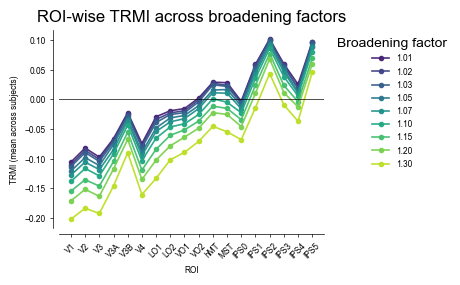

In [11]:
roi_order = list(ROIs_list_long)
palette = sns.color_palette("viridis", n_colors=df_group["factor"].nunique())

fig, ax = plt.subplots(figsize=cm_to_inch(12, 7.5))
for i, factor in enumerate(sorted(df_group["factor"].unique())):
    sub = df_group[df_group["factor"] == factor].copy()
    sub["ROI"] = pd.Categorical(sub["ROI"], categories=roi_order, ordered=True)
    sub = sub.sort_values("ROI")
    ax.plot(
        sub["ROI"],
        sub["TRMI_mean"],
        marker="o",
        linewidth=1.2,
        markersize=3,
        color=palette[i],
        alpha=0.95,
        label=f"{factor:.2f}",
    )

ax.set_xlabel("ROI")
ax.set_ylabel("TRMI (mean across subjects)")
ax.set_title("ROI-wise TRMI across broadening factors")
ax.axhline(0, color="black", linewidth=0.7, alpha=0.7)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Broadening factor", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine(offset=4)
plt.tight_layout()
plt.show()
fig.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_sharpeninganalysis_responseletter.png", dpi=600, bbox_inches='tight')

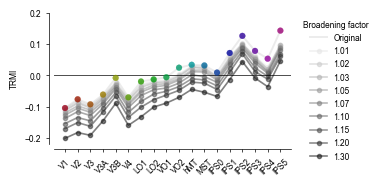

In [9]:
roi_order = list(ROIs_list_long)
palette = sns.color_palette("gray", n_colors=df_group["factor"].nunique())[::-1]
gist_rainbow_desaturated_3 = desaturate_palette(
    plt.colormaps.get_cmap("gist_rainbow"), saturation=1.0, lightness=0.6
 )
gist_rainbow_sampled_3 = sample_cmap(gist_rainbow_desaturated_3, len(roi_order))

fig, ax = plt.subplots(figsize=cm_to_inch(10, 5))


if original_records:
    df_original = pd.DataFrame(original_records)
    df_original_group = _group_roi_values_like_hierarchy(df_original)
    ax.plot(
        df_original_group["ROI"],
        df_original_group["TRMI_mean"],
        linewidth=1.4,
        color="0.25",
        alpha=0.1,
        label="Original",
        zorder=3,
    )
    ax.scatter(
        df_original_group["ROI"],
        df_original_group["TRMI_mean"],
        s=18,
        c=gist_rainbow_sampled_3,
        edgecolors=gist_rainbow_sampled_3,
        linewidths=0.2,
        alpha=0.8,
        label="_nolegend_",
        zorder=3,
    )


for i, factor in enumerate(sorted(df_group["factor"].unique())):
    sub = df_group[df_group["factor"] == factor].copy()
    sub["ROI"] = pd.Categorical(sub["ROI"], categories=roi_order, ordered=True)
    sub = sub.sort_values("ROI")
    ax.plot(
        sub["ROI"],
        sub["TRMI_mean"],
        marker="o",
        linewidth=1.2,
        markersize=3,
        color=palette[i],
        alpha=0.55,
        label=f"{factor:.2f}",
        zorder=2,
    )


ax.set_xlabel("")
ax.set_ylabel("TRMI")
# ax.set_title("ROI-wise TRMI across broadening factors")
ax.set_yticks([-0.2,-0.1, 0, 0.1, 0.2])
ax.axhline(0, color="black", linewidth=0.7, alpha=0.7)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Broadening factor", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title_fontsize=6)
sns.despine(offset=4)
plt.tight_layout()
plt.show()
fig.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_sharpeninganalysis.png", dpi=600, bbox_inches='tight')
fig.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_sharpeninganalysis.pdf", dpi=600, bbox_inches='tight')

## Subject-level TRMI across ROI

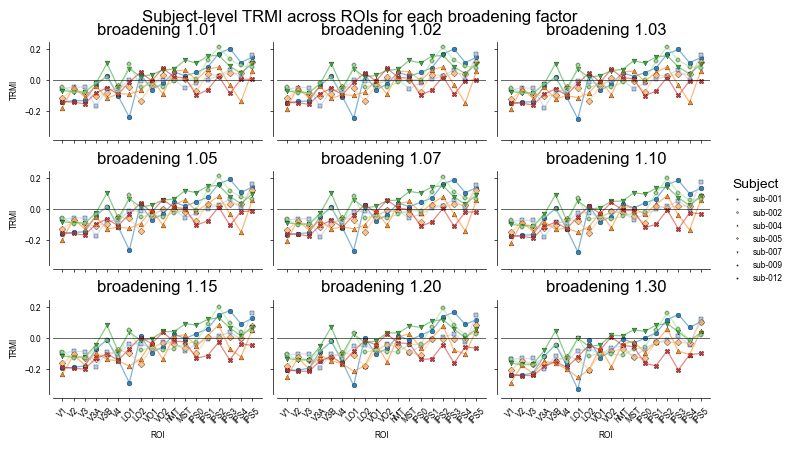

In [10]:
roi_order = list(ROIs_list_long)
factor_order = sorted(df_roi_trmi["factor"].unique())
subject_order = sorted(df_roi_trmi["subject"].unique())

# Provide a marker per subject. If subjects exceed this pool, markers are reused.
marker_pool = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "8", "p", "d"]
subject_marker_map = {
    subj: marker_pool[i % len(marker_pool)] for i, subj in enumerate(subject_order)
}
subject_palette = sns.color_palette("tab20", n_colors=len(subject_order))
subject_color_map = {subj: subject_palette[i] for i, subj in enumerate(subject_order)}

ncols = 3
nrows = int(np.ceil(len(factor_order) / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=cm_to_inch(6 * ncols, 3.6 * nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)

x_map = {roi: i for i, roi in enumerate(roi_order)}

for i, factor in enumerate(factor_order):
    ax = axes[i // ncols, i % ncols]
    sub_factor = df_roi_trmi[df_roi_trmi["factor"] == factor].copy()

    for subject in subject_order:
        sub_line = sub_factor[sub_factor["subject"] == subject].copy()
        sub_line["ROI"] = pd.Categorical(sub_line["ROI"], categories=roi_order, ordered=True)
        sub_line = sub_line.sort_values("ROI")

        if sub_line.empty:
            continue

        x_line = np.array([x_map[r] for r in sub_line["ROI"]])
        y_line = sub_line["TRMI_mean"].to_numpy()

        ax.plot(
            x_line,
            y_line,
            color=subject_color_map[subject],
            linewidth=0.9,
            alpha=0.55,
        )
        ax.scatter(
            x_line,
            y_line,
            marker=subject_marker_map[subject],
            s=12,
            color=subject_color_map[subject],
            edgecolors="black",
            linewidths=0.25,
            alpha=0.9,
        )

    ax.axhline(0, color="black", linewidth=0.6, alpha=0.7)
    ax.set_title(f"broadening {factor:.2f}")
    ax.set_xticks(range(len(roi_order)))
    ax.tick_params(axis="x", rotation=45)

    ax.set_xticklabels(roi_order, rotation=45, ha="right")
    sns.despine(ax=ax, offset=3)

for j in range(len(factor_order), nrows * ncols):
    axes[j // ncols, j % ncols].axis("off")

for ax in axes[:, 0]:
    ax.set_ylabel("TRMI")
for ax in axes[-1, :]:
    ax.set_xlabel("ROI")

subject_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=subject_marker_map[subj],
        color=subject_color_map[subj],
        linestyle="none",
        markeredgecolor="black",
        markeredgewidth=0.3,
        markersize=1,
        label=subj,
    )
    for subj in subject_order
]
fig.legend(
    handles=subject_handles,
    title="Subject",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    ncol=1,
)

fig.suptitle("Subject-level TRMI across ROIs for each broadening factor", y=1.02)
plt.show()
fig.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_sharpeninganalysis_subjects.png", dpi=600, bbox_inches='tight')